<h1>24 - Apprentissage non supervisé avec Python</h1>

Lien Vidéo tuto: <a href="https://www.youtube.com/watch?v=w_bLGK4Pteo&list=PLO_fdPEVlfKqMDNmCFzQISI2H_nJcEDJq&index=22">TAPPRENTISSAGE NON-SUPERVISÉ avec Python (24/30)</a> (durée : 41 min)

L'apprentissage non supervisé est la seconde approche très connue du Machine et du Deep Learning. On va voir ci-dessous quelles sont les 3 applications les plus importantes qui sont : 
- le clustering
- la déterction d'anomalie 
- la réduction de dimension

Pour commencer, il faut comprendre ce qu'est l'apprentissage non-supervisé. Il s'agit d'une méthode d'apprentissage dans laquelle, au lieu de montrer à la machine des exemples $(X, y)$ de ce qu'elle doit apprendre, on lui founit uniquement des données $X$ et on lui demande d'analyser la structure de ces données pour apprendre, elle-même, à réaliser certaines taches. 

Par exemple, le machine peut apprendre à classer des données en se basant uniquement sur leur ressemblance. On parle de CLUSTERING. Cette technique peut permettre de faire beaucoup de choses, comme classer des documents, des photos, des Tweets, segmenter la clientèle d'une entreprisen etc ... Ici, on va voir comment réaliser ce type de taches avec l'algorithme `K-Means Clustering`.

Une autre tache que la machine peut faire grâce à l'apprentissage non supervisé est, la détection d'anomalie. Pour cela, la machine analyse la structure de nos données, et parvient à trouver les échantillons dont les caractéristiques sont très éloignées de celles des autres échantillons. Et ça, ça nous permet de développer :
- des systèmes de sécurité 
- des systèmes de détection de fraude bancaire (hacking)
- des systèmes de détection de défaillance sur des pièces dans une usine 
Ici, on va voir comment réaliser ce type de tâche à partir du modèle `Isolation Forest`

Enfin, une technique très populaire de l'apprentissage non supervisé est la réduction de dimensionnalité. C'est-à-dire, qu'en analysant la structure de nos données, ma machine apprend comment simplifier cette structure tout en conservant les principales informations. Par exemple, c'est comme si la machine apprend la structure d'un dessin et apprend à redessiner ce dessins de manière plus simple tout en conservant les principaux éléments. Sur le plan mathématique, la machine apprend à projeter nos données dans des espaces de plus petite dimension. Un des alhorithmes qui permet de faire cela est l'agorythme `PCA` (Analyse en composante principale). À noter que les applications de cet algorithme sont absolument géniales. En effet, on peut non seulement simplifier la complexité superflue que peut avoir un dataset, ce qui facilite alors beaucoup l'apprentissage de la machine pour des problèmes de régression ou de classification, mais on peut également visualiser en 2D ou 3D des espaces qui vont bien au delà de notre imagination.

À noter qu'ici, on va apprendre à implémenter ces 3 algorithmes en utilisant scikit-learn. 


<h2>Setup</h2>

In [4]:
# Standard libraries
from sklearn.datasets import make_blobs

# Visualization libraries
import matplotlib.pyplot as plt

# ML libraries
from sklearn.cluster import KMeans

<h2>Clustering</h2>

On va commencer avec le Clustering. Le principe est de laisser la machine apprendre à classer nos données en fonction de leur ressemblance. Pour cela, un des algorithme les plus populaire en ce moment est le `K-Means Clustering`.

Supposons qu'on ait un ensemble de données et qu'on souhaite les regrouper en 3 clusters. Pour cela, on va commencer à placer 3 points appelés centroïdes, au hasard parmi nos données. Ensuite, on affecte chacun de nos points de donnés au centroïde le plus proche. Ce qui nous donne 3 clusters. Puis, on déplace chaque centroïde au milieu de son cluster. Ensuite, on recommance, on affecte à nouveau chaque point de notre dataset au centreoïde le plus proche, et on déplace à nouveau chaque centroïde au centre de son cluster. On va procéder ainsi, de manière itérative, jusqu'à ce que les centroïdes convergent vers une position d'équilibre. 

On l'aura compris, l'algorithme `K-Means Clustering` est en réalité un algorithme itératif qui fonctionne en deux étapes :
- 1er étape : on affecte les points des datasets aux centreoïdes les plus proches 
- 2nd étape : on calcule la moyenne de chaque cluster et on y déplace le centroïde

Attention, c'est possible qu'à cause de la localisation initiale de nos centroïdes, ces derniers convergent vers de mauvaises positions. Heureusement, il existe une solution pour éviter ça. Pour cela, on va exécuter l'algorithme de `K-Mean Clustering` plusieurs fois d'à filé, en modifiant à chaque fois la position initiale de nos centroïdes. Pour chaque résultat, on mesure la distance entre les points de chaque cluster et leur centroïde, et on retient la solution pour laquelle la somme de ces distances est la plus petite. 

En résumé, l'algorithme de `K-Means Clustering` cherche en faite à minimiser une fonction coût, appelée `inertia`, qui représente la distance entre les points d'un cluster ($x_i$) et le centre de ce dernier ($\mu _j$) : $\sum^n_{i=0}min(||x_i - \mu _j ||^2)$. 
Et cela, ressemble à peu de choses prêt, à la variance de nos cluster. On peut donc dire que cet algo cherche à minimiser la variance des clusters.

<h3><u>Implémenter un modèle KMeans Clustering</u></h3>

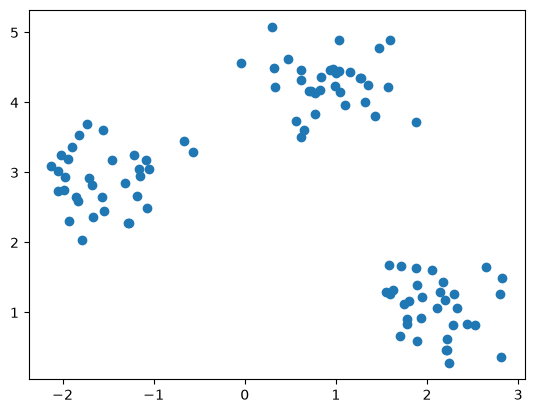

In [17]:
# Generate synthetic data
X, y = make_blobs(n_samples=100, centers=3, cluster_std=0.4, random_state=0)

# Display the generated data
plt.scatter(X[:, 0], X[:, 1])

In [18]:
# Instantiate the model 
model = KMeans(n_clusters=3)

Si on avait voulu, on aurait également pu :
- définir le nombre d'initialisation qu'on aurait voulu pour notre algorithme avec le paramètre `n_init`. C'est-à-dire, le nombre de fois que l'amgorithme sera exécuté. Par défaut, ce paramètre est fixé à 10
- définir le nombre d'itération max avec le paramètre `max_iter`. Par défaut, cette valeur doit être fixée autour de 200 ou 300.
- définir quelle stratégie d'initialisaton on va utiliser, avec le paramètre `init`. Par défaut, c'est la méthode `K-Means++` qui est utilisée. Cette technique permet de placer nos centroïdes sur des points trés éloignés de notre dataset, ceci dans le but d'accélérer la convergence de nos centroïdes vers des positions d'équilibre. C'est déjà une très bonne technique d'initialisation donc Guillaume nous conseille de ne pas y toucher.

En définitive, quand on utilise le modèle KMeans, la seule chose qu'il reste à faire est d'indiquer le nombre de cluster qu'on chercher à obtenir en sortie.

Show to each cluster each data point belongs:
 [1 0 1 0 0 0 2 2 1 0 0 0 1 0 2 1 2 0 2 2 2 2 2 0 1 1 1 1 2 2 0 1 1 0 2 2 0
 1 1 2 2 1 1 0 0 0 1 1 2 2 2 1 0 1 2 2 1 1 0 1 1 2 2 2 2 1 0 2 1 0 2 0 0 1
 1 0 0 0 2 1 0 0 1 0 1 0 0 0 1 0 1 1 2 2 2 2 0 0 2 2]
Show to each cluster each data point belongs:
 [1 0 1 0 0 0 2 2 1 0 0 0 1 0 2 1 2 0 2 2 2 2 2 0 1 1 1 1 2 2 0 1 1 0 2 2 0
 1 1 2 2 1 1 0 0 0 1 1 2 2 2 1 0 1 2 2 1 1 0 1 1 2 2 2 2 1 0 2 1 0 2 0 0 1
 1 0 0 0 2 1 0 0 1 0 1 0 0 0 1 0 1 1 2 2 2 2 0 0 2 2]

Centroïds coodinates:
 [[ 0.92702654  4.27385438]
 [ 2.08889087  1.07930405]
 [-1.55022199  2.90542155]]


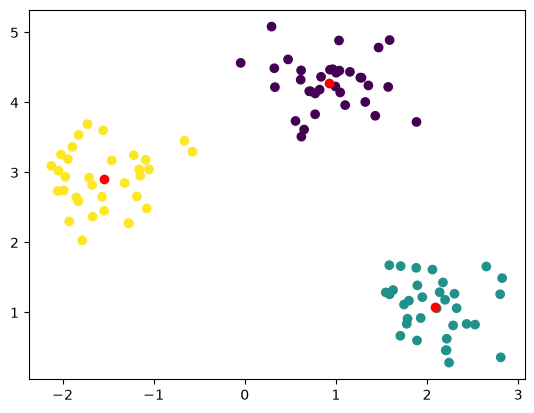

In [19]:

# Train de model using X data
model.fit(X)

# Display the clusters : 2 methods
print(f"Show to each cluster each data point belongs:\n {model.labels_}")
print(f"Show to each cluster each data point belongs:\n {model.predict(X)}") # Better to use it on new inputs

# Display the centroïds coordinates 
print(f"\nCentroïds coodinates:\n {model.cluster_centers_}")

# Build the graphic to show each cluster with its centroïd
# -- x----------------------x --
# Display the data with a specific color for each cluster
plt.scatter(X[:,0], X[:, 1], c=model.predict(X)) # With X[:,0] the x coordinate and X[:, 1] the y coordinate
# Add the centroïds on the graphic
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='r')
# -- x----------------------x --


In [ ]:
# Display the model inertia
print(f"Model inertia: {model.inertia_}")


# Display the model scores, that is the inertia but negative
model.score(X)

Model inertia: 30.870531280140682


-30.870531280140675

Ainsi, l'inertia, c'est-à-dire la somme des distances entre les points d'un cluster et son centroïde. Ici elle est environ de 30.5, l'unité étant celle de nos données de notre dataset (cm, euro, litre, ...)

Note : 
Une autre chose sympas qu'on peut faire avec un modèle `K-Means Clustering` est de l'utiliser comme un transformer. En effet, il existe des méthodes telle que `.fit_transform()` qui retourne la distance entre chaque point d'un cluster et son centroïde. 

<h3><u>The Elbow Method</u></h3>

On a compris comment implémenter rapidement le modèle `K-Means Clustering`, mais comment être sûr qu'on a définit le bon nombre de cluster pour notre algorithme. Dans notre cas, visuellement c'était assez facile de déterminer combien de cluster on allait chercher à définir. Mais dans le cas où on se trouve en présence d'un dataset avec des centaines de dimensions, dans lequel, nos données sont un peu mélangées, ce n'est pas du tout évident. 

Pour cela, on peut avoir recour à la `Elbow Method` qui consiste à tracer l'évolution du coût de notre modèle en fonction du nombre de clusters, et de détecter dans ce graphique une zone de coude. C'est cette zone qui nous indique le nombre de clusters optimal. C'est-à-dire le nombre de clusters qui nous permet de réduire au maximum le coût de notre modèle, tout en conservant un nombre raisonnable de clusters.

In [22]:
# Instantiate an empty list to store the inertia values 
inertia = []

# Define a range for the cluster numbers
K_range = range(1, 20)

In [23]:
# Itératively train the KMeans Clustering model to get each inertia
for k in K_range:
    # Instantiate and train the model
    model = KMeans(n_clusters=k).fit(X)
    # Extract the inertia and add it to the list
    inertia.append(model.inertia_)

Text(0, 0.5, 'Model cost (Inertia)')

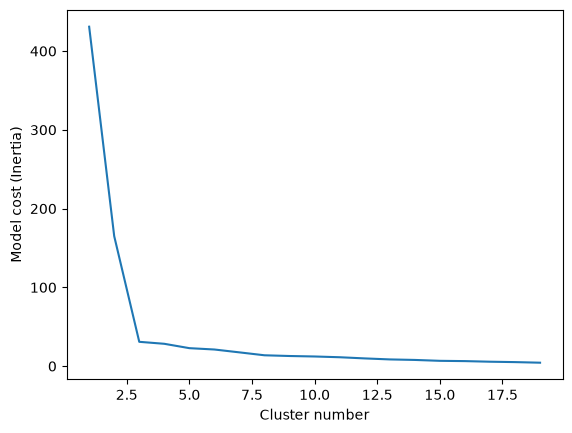

In [24]:
# Build a graph to display the inertia evolution in function of the number of cluster
plt.plot(K_range, inertia)
plt.xlabel("Cluster number")
plt.ylabel("Model cost (Inertia)")

En observant le graphique, on observe qu'il existe une zone de coude pour $K = 3$. Ce qui est parfaitement cohérent avec l'allure de nos données.

Dans `Scikit-Learn`, il existe de nombreux algorithmes de clustering en plus du `KMeans Clustering`. S'il fallait on retenir que quelques uns, on pourrait citer :
- `DBSAN` : pour "Densiy-based spatial clustering or application with noise" (`cluster.DBSCAN`)
- `AgglomerativeClustering` : hierarchical clustering (`cluster.AgglomerativeClustering`)
- `Spectral Clustering` : (`cluster.SpectralCoclustering`)

Les deux premiers sont très utiles quand on souhaite segmenter des données qui forment des clusters non-convexe ou anisotropes. Sur de tels cas de figures, ils donneront de meilleurs résultats que `KMeans Clustering`

<h2>Détection d'anomalie</h2>

Comme on a pu le voir au début de la vidéo, la détection d'anomalie requière des techniques d'apprentissage non-suprvisées, qui consiste à détecter dans notre dataset les échantillons dont les caractéristiques $X$ sont très éloignées de celles des autres échantillons. Pour cela, on peut par exemple calculer la moyenne et l'écart type de nos données, pour déterminer une fonction `densité de probabilité` et se servir de cette fonction pour calculer la probabilité d'existance d'un échantillon donné. Si cette probabilité est en dessous d'un certain seuil, alors l'échantillon est considéré comme anormal.

Cette technique fonctionne très bien, mais ici, on va présenter une méthode plus moderne et plus efficace pour faire ce genre de choses. C'est méthode, c'est l'algorithme `Isolation Forest`.

L'idée est la suivante: dans notre dataset, on va effectuer. ... reprendre à 15:45